In [34]:
# Sklearn imports
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import numpy as np

# DiCE imports
import dice_ml
from dice_ml.utils import helpers  # helper functions

In [3]:
%load_ext autoreload
%autoreload 2

import os
os.environ["PATH"] += os.pathsep + "/opt/homebrew/bin"

In [4]:
dataset = helpers.load_adult_income_dataset()
target = dataset["income"].astype(int)

In [5]:
train_dataset, test_dataset, y_train, y_test = train_test_split(dataset,
                                                                target,
                                                                test_size=0.2,
                                                                random_state=0,
                                                                stratify=target)
x_train = train_dataset.drop('income', axis=1)
x_test = test_dataset.drop('income', axis=1)

In [6]:
# Step 1: dice_ml.Data
d = dice_ml.Data(
    dataframe=train_dataset, 
    continuous_features=['age', 'hours_per_week'], 
    categorical_features_ordering={'education': ['School', 'HS-grad', 'Some-college', 'Assoc', 'Bachelors', 'Masters', 'Prof-school', 'Doctorate']},
    outcome_name='income'
)


In [7]:
# step 2 constraints
constraints = dice_ml.CausalConstraints(data_interface=d)
constraints.add_single_constraint("cannot_decrease", feature="age")
constraints.add_single_constraint("cannot_decrease", feature="education")
constraints.add_single_constraint("cannot_change", feature="race")
constraints.add_single_constraint("cannot_change", feature="gender")
constraints.add_constraint("increase_with", feature="age", depends_on="education")
constraints.add_constraint("increase_on_change", feature="age", depends_on="marital_status")
# constraints.create_constraint_visualisation()

# print(constraints.constraints)

In [8]:
backend = 'TF2'  # needs tensorflow installed
ML_modelpath = helpers.get_adult_income_modelpath(backend=backend)
# Step 2: dice_ml.Model
m = dice_ml.Model(model_path=ML_modelpath, backend=backend, func="ohe-min-max")

In [9]:
# Step 3: initiate DiCE
exp = dice_ml.Dice(d, m, method="gradient")

/Users/izzimillar/Documents/cam/part_iii/L193/DiCE/.venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/izzimillar/Documents/cam/part_iii/L193/DiCE/.venv/lib/python3.11/site-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


In [29]:
import random
random.seed(42)

random_ids = random.sample(list(x_test.index), 1)
random_instaces = x_test.loc[random_ids]


In [ ]:
def display_graph(values, no_cfs, title="", ylim=None, ylabel="", marker='*'):
    plt.plot(no_cfs, values, marker)
    plt.title(title)
    plt.ylim(ylim)
    plt.xlabel("Number of cfs")
    plt.ylabel(ylabel)
    plt.show()
    

In [30]:
cat_div = []
cat_prox = []
cont_div = []
cont_prox = []
count_div = []
spars = []
val = []

for i in range(5):
	cfs = exp.generate_counterfactuals(random_instaces, total_CFs=i+1, desired_class="opposite", causal_constraints=constraints)

	cat_div.append(cfs.calculate_cat_diversity())
	cat_prox.append(cfs.calculate_cat_proximity())
	cont_div.append(cfs.calculate_cont_diversity())
	cont_prox.append(cfs.calculate_cont_proximity())
	spars.append(cfs.calculate_cont_sparsity())
	count_div.append(cfs.calculate_count_diversity())
	val.append(cfs.calculate_validity(i+1))



  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:09<00:00,  9.54s/it]


Diverse Counterfactuals found! total time taken: 00 min 09 sec


100%|██████████| 1/1 [00:15<00:00, 15.19s/it]


Diverse Counterfactuals found! total time taken: 00 min 15 sec


...

Diverse Counterfactuals found! total time taken: 00 min 31 sec


100%|██████████| 1/1 [00:32<00:00, 32.53s/it]


Diverse Counterfactuals found! total time taken: 00 min 32 sec


100%|██████████| 1/1 [00:47<00:00, 47.10s/it]

Diverse Counterfactuals found! total time taken: 00 min 46 sec


In [33]:
print(cat_div)
print(cat_prox)
print(cont_div)
print(cont_prox)
print(count_div)
print(spars)
print(val)

[0.0, 0.3333333333333333, 0.38888888888888884, 0.3055555555555555, 0.2833333333333334]
[0.6666666666666667, 0.5833333333333334, 0.6111111111111112, 0.625, 0.7]
[0.0, np.float64(1.75), np.float64(2.3666666666666667), np.float64(3.0375), np.float64(4.1450000000000005)]
[np.float64(-1.925), np.float64(-1.375), np.float64(-1.95), np.float64(-3.0062499999999996), np.float64(-3.255)]
[0.0, 0.5, 0.5416666666666666, 0.47916666666666663, 0.4625]
[1.0, 0.75, 0.8333333333333333, 1.0, 1.0]
[1.0, 1.0, 1.0, 1.0, 1.0]


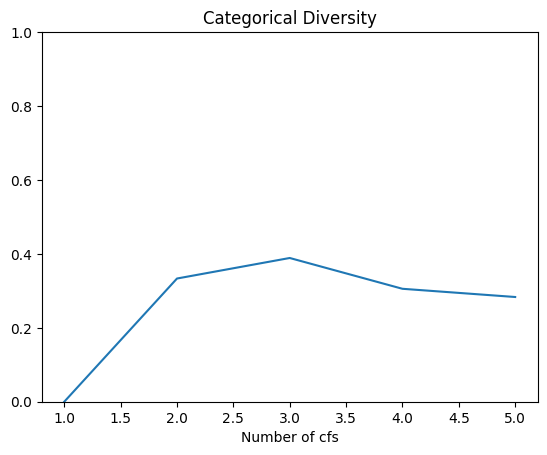

In [38]:
display_graph(cat_div, np.arange(1, 6), title="Categorical Diversity", ylim=(0, 1.0))

In [ ]:
ncat_div = []
ncat_prox = []
ncont_div = []
ncont_prox = []
ncount_div = []
nspars = []
nval = []
for i in range(5):
	cfs = exp.generate_counterfactuals(random_instaces, total_CFs=i+1, desired_class="opposite")

	ncat_div.append(cfs.calculate_cat_diversity())
	ncat_prox.append(cfs.calculate_cat_proximity())
	ncont_div.append(cfs.calculate_cont_diversity())
	ncont_prox.append(cfs.calculate_cont_proximity())
	nspars.append(cfs.calculate_cont_sparsity())
	ncount_div.append(cfs.calculate_count_diversity())
	nval.append(cfs.calculate_validity(i+1))

In [ ]:
print(ncat_div)
print(ncat_prox)
print(ncont_div)
print(ncont_prox)
print(ncount_div)
print(nspars)
print(nval)